In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("task2_cleaned_weather_data.xlsx")
df["time"] = pd.to_datetime(df["time"])

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 1830 rows × 13 columns


In [2]:
city_profile = df.groupby("city").agg(
    avg_temp        = ("temperature_2m_mean",       "mean"),
    avg_max_temp    = ("temperature_2m_max",         "mean"),
    avg_min_temp    = ("temperature_2m_min",         "mean"),
    avg_rainfall    = ("precipitation_sum",          "mean"),
    avg_humidity    = ("relative_humidity_2m_mean",  "mean"),
    avg_wind        = ("windspeed_10m_max",          "mean"),
    rainy_days      = ("precipitation_sum",          lambda x: (x > 1).sum()),
    total_days      = ("precipitation_sum",          "count"),
).reset_index()

city_profile["rain_day_pct"] = (city_profile["rainy_days"] / city_profile["total_days"] * 100).round(1)
city_profile = city_profile.round(2)

print("City Weather Profiles:")
city_profile

City Weather Profiles:


,city,avg_temp,avg_max_temp,avg_min_temp,avg_rainfall,avg_humidity,avg_wind,rainy_days,total_days,rain_day_pct
0,Accra,26.96,30.53,24.31,2.50,81.96,17.64,189,366,51.6
1,Bawku,28.84,34.87,23.82,2.37,49.31,15.74,95,366,26.0
2,Kumasi,26.47,31.91,22.84,4.00,76.34,12.58,187,366,51.1
3,Takoradi,26.39,30.57,23.52,4.18,84.86,12.71,268,366,73.2
4,Tamale,28.58,34.09,23.94,2.78,56.51,15.19,114,366,31.1


In [3]:
def recommend_city(
    preferred_temp=None,       # °C  e.g. 28
    max_humidity=None,         # %   e.g. 70
    max_rainfall=None,         # mm  e.g. 2
    prefer_low_wind=False,     # True/False
    prefer_dry=False,          # True/False (fewer rainy days)
    top_n=3
):
    scores = city_profile.copy()
    scores["score"] = 0.0

    # Temperature preference
    if preferred_temp is not None:
        temp_diff = (scores["avg_temp"] - preferred_temp).abs()
        scores["score"] += (1 / (temp_diff + 1)) * 40

    # Humidity preference
    if max_humidity is not None:
        scores["score"] += scores["avg_humidity"].apply(
            lambda x: 20 if x <= max_humidity else 0
        )

    # Rainfall preference
    if max_rainfall is not None:
        scores["score"] += scores["avg_rainfall"].apply(
            lambda x: 20 if x <= max_rainfall else 0
        )

    # Wind preference
    if prefer_low_wind:
        wind_score = 1 / (scores["avg_wind"] + 1)
        scores["score"] += (wind_score / wind_score.max()) * 10

    # Dry days preference
    if prefer_dry:
        dry_score = 1 / (scores["rain_day_pct"] + 1)
        scores["score"] += (dry_score / dry_score.max()) * 10

    result = scores.sort_values("score", ascending=False).head(top_n)

    print("=" * 55)
    print("   CITY WEATHER RECOMMENDATIONS")
    print("=" * 55)
    for rank, (_, row) in enumerate(result.iterrows(), 1):
        print(f"\n  #{rank} — {row['city']}")
        print(f"       Avg Temp     : {row['avg_temp']:.1f}°C")
        print(f"       Avg Humidity : {row['avg_humidity']:.1f}%")
        print(f"       Avg Rainfall : {row['avg_rainfall']:.2f}mm/day")
        print(f"       Avg Wind     : {row['avg_wind']:.1f}km/h")
        print(f"       Rainy Days   : {int(row['rainy_days'])} ({row['rain_day_pct']}%)")
        print(f"       Match Score  : {row['score']:.2f}")
    print("\n" + "=" * 55)

    return result

print("Recommender function ready.")

Recommender function ready.


In [4]:
# Example 1: Someone who likes warm but not too hot, low humidity
print("Query: Warm (~28°C), low humidity, prefer dry days\n")
result1 = recommend_city(
    preferred_temp=28,
    max_humidity=70,
    prefer_dry=True,
    top_n=3
)

Query: Warm (~28°C), low humidity, prefer dry days

   CITY WEATHER RECOMMENDATIONS

  #1 — Tamale
       Avg Temp     : 28.6°C
       Avg Humidity : 56.5%
       Avg Rainfall : 2.78mm/day
       Avg Wind     : 15.2km/h
       Rainy Days   : 114 (31.1%)
       Match Score  : 53.73

  #2 — Bawku
       Avg Temp     : 28.8°C
       Avg Humidity : 49.3%
       Avg Rainfall : 2.37mm/day
       Avg Wind     : 15.7km/h
       Rainy Days   : 95 (26.0%)
       Match Score  : 51.74

  #3 — Accra
       Avg Temp     : 27.0°C
       Avg Humidity : 82.0%
       Avg Rainfall : 2.50mm/day
       Avg Wind     : 17.6km/h
       Rainy Days   : 189 (51.6%)
       Match Score  : 24.74



In [5]:
# Example 2: Someone who doesn't mind rain, wants coolest city
print(" Query: Coolest city, low wind\n")
result2 = recommend_city(
    preferred_temp=25,
    prefer_low_wind=True,
    top_n=3
)

 Query: Coolest city, low wind

   CITY WEATHER RECOMMENDATIONS

  #1 — Takoradi
       Avg Temp     : 26.4°C
       Avg Humidity : 84.9%
       Avg Rainfall : 4.18mm/day
       Avg Wind     : 12.7km/h
       Rainy Days   : 268 (73.2%)
       Match Score  : 26.64

  #2 — Kumasi
       Avg Temp     : 26.5°C
       Avg Humidity : 76.3%
       Avg Rainfall : 4.00mm/day
       Avg Wind     : 12.6km/h
       Rainy Days   : 187 (51.1%)
       Match Score  : 26.19

  #3 — Accra
       Avg Temp     : 27.0°C
       Avg Humidity : 82.0%
       Avg Rainfall : 2.50mm/day
       Avg Wind     : 17.6km/h
       Rainy Days   : 189 (51.6%)
       Match Score  : 20.80



In [6]:
# Example 3: Best city for harmattan (dry, windy, hot)
print(" Query: Hot (~32°C), dry, doesn't mind wind\n")
result3 = recommend_city(
    preferred_temp=32,
    max_rainfall=1,
    prefer_dry=True,
    top_n=3
)

 Query: Hot (~32°C), dry, doesn't mind wind

   CITY WEATHER RECOMMENDATIONS

  #1 — Bawku
       Avg Temp     : 28.8°C
       Avg Humidity : 49.3%
       Avg Rainfall : 2.37mm/day
       Avg Wind     : 15.7km/h
       Rainy Days   : 95 (26.0%)
       Match Score  : 19.62

  #2 — Tamale
       Avg Temp     : 28.6°C
       Avg Humidity : 56.5%
       Avg Rainfall : 2.78mm/day
       Avg Wind     : 15.2km/h
       Rainy Days   : 114 (31.1%)
       Match Score  : 17.46

  #3 — Accra
       Avg Temp     : 27.0°C
       Avg Humidity : 82.0%
       Avg Rainfall : 2.50mm/day
       Avg Wind     : 17.6km/h
       Rainy Days   : 189 (51.6%)
       Match Score  : 11.76



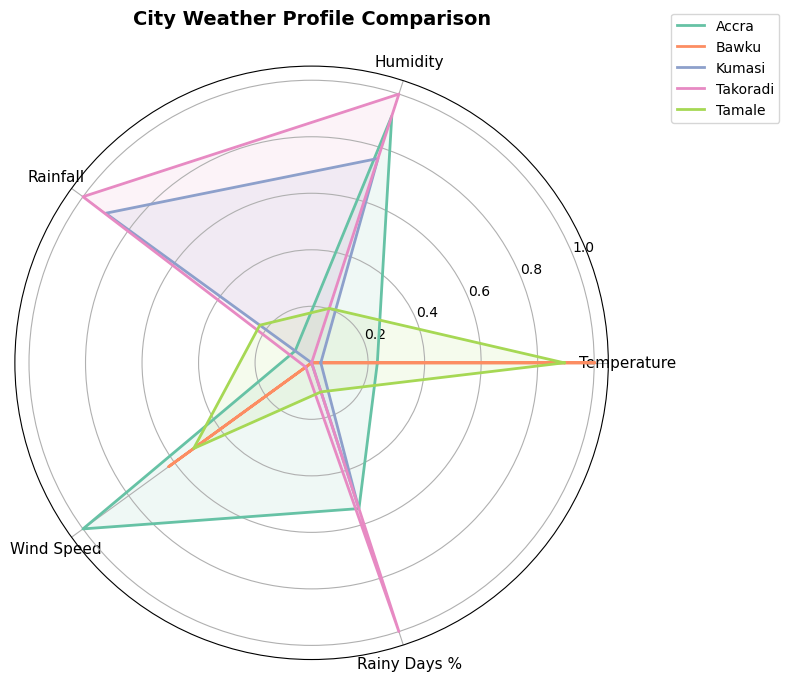

In [7]:
categories = ["avg_temp", "avg_humidity", "avg_rainfall", 
              "avg_wind", "rain_day_pct"]
labels      = ["Temperature", "Humidity", "Rainfall", 
               "Wind Speed", "Rainy Days %"]

# Normalize each metric to 0–1
profile_norm = city_profile.copy()
for col in categories:
    col_min = profile_norm[col].min()
    col_max = profile_norm[col].max()
    profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)

N      = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette("Set2", len(city_profile))

for i, row in profile_norm.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["city"], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("City Weather Profile Comparison\n", 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("chart5c_city_radar.png", dpi=150, bbox_inches='tight')
plt.show()

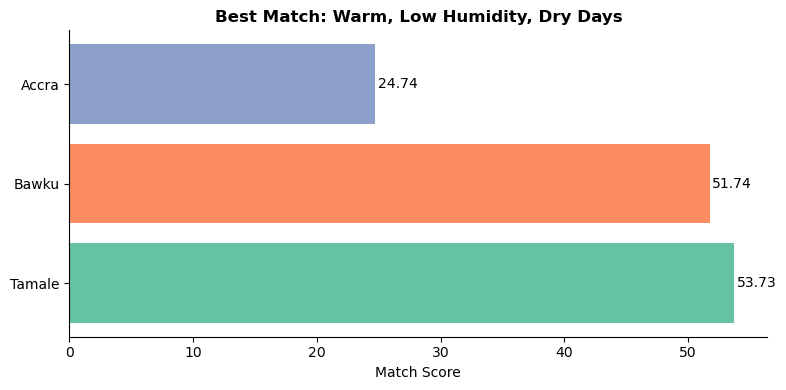

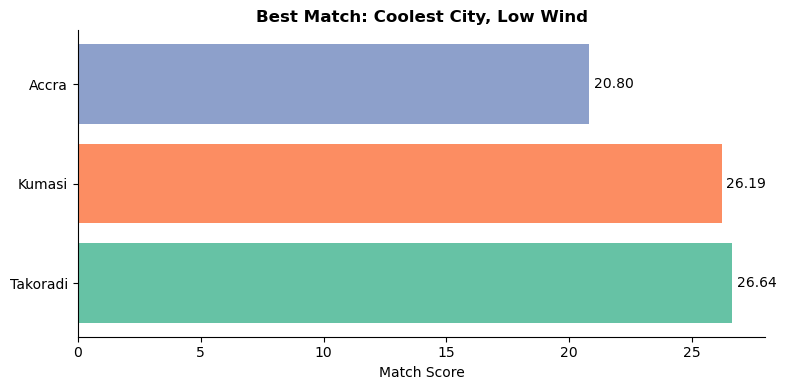

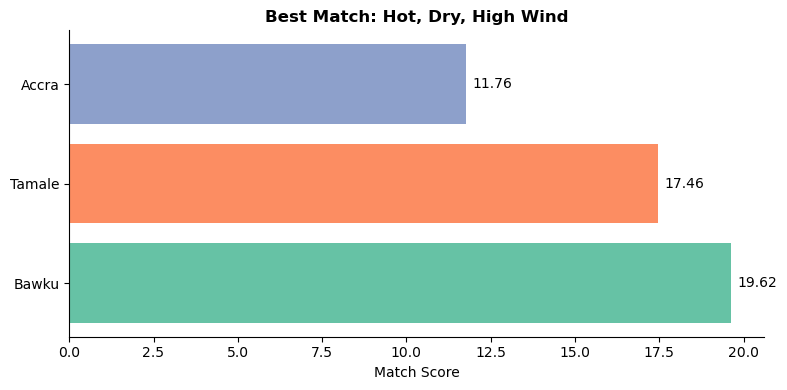

In [8]:
def plot_scores(result, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = sns.color_palette("Set2", len(result))
    bars = ax.barh(result["city"], result["score"], color=colors)
    ax.set_xlabel("Match Score")
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, result["score"]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va='center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_scores(result1, "Best Match: Warm, Low Humidity, Dry Days")
plot_scores(result2, "Best Match: Coolest City, Low Wind")
plot_scores(result3, "Best Match: Hot, Dry, High Wind")

In [9]:
with pd.ExcelWriter("task5c_recommender_results.xlsx", engine="openpyxl") as writer:
    city_profile.to_excel(writer, sheet_name="City Profiles", index=False)
    result1.to_excel(writer, sheet_name="Query 1 - Warm Dry", index=False)
    result2.to_excel(writer, sheet_name="Query 2 - Cool Low Wind", index=False)
    result3.to_excel(writer, sheet_name="Query 3 - Hot Dry", index=False)

print("Saved: task5c_recommender_results.xlsx")

Saved: task5c_recommender_results.xlsx
